In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# Data Loading and Cleaning

In [4]:
# Load Data
airlines = pd.read_csv("data/airlines.csv")
airports = pd.read_csv("data/airports.csv")
flights = pd.read_csv("data/flights.csv", low_memory=False)

### Fix 5-digit airport codes to standard 3-character IATA codes

In [5]:
#fix from https://github.com/lezandar/flights
aircode1 = pd.read_csv('data/L_AIRPORT.csv')
aircode2 = pd.read_csv('data/L_AIRPORT_ID.csv')

# Format the airport codes
aircode1 = aircode1.reset_index()
aircode2 = aircode2.reset_index()

In [6]:
aircodes = pd.merge(aircode1,aircode2,on='Description')
aircode_dict = dict(zip(aircodes['Code_y'].astype(str),aircodes['Code_x']))

In [7]:
# Make sure all Origin and departing airports are strings
flights['ORIGIN_AIRPORT'] = flights['ORIGIN_AIRPORT'].values.astype(str)
flights['DESTINATION_AIRPORT'] = flights['DESTINATION_AIRPORT'].values.astype(str)

In [ ]:
for i in range(len(flights)):
    if len(flights['ORIGIN_AIRPORT'][i]) != 3:
        to_replace = flights['ORIGIN_AIRPORT'][i]
        value = aircode_dict[flights['ORIGIN_AIRPORT'][i]]
        flights = flights.replace(to_replace, value)

for i in range(len(flights)):
    if len(flights['DESTINATION_AIRPORT'][i]) != 3:
        to_replace = flights['DESTINATION_AIRPORT'][i]
        value = aircode_dict[flights['DESTINATION_AIRPORT'][i]]
        flights = flights.replace(to_replace, value)

### Remove flights to and from BSM

In [34]:
flights_filtered_bsm = flights[
    (flights['ORIGIN_AIRPORT'] != 'BSM') &
    (flights['DESTINATION_AIRPORT'] != 'BSM')
]

In [35]:
len(flights) - len(flights_filtered_bsm)

8035

In [36]:
flights_filtered_bsm.to_csv('data/flights_filtered_fixed.csv', index=False)

# Feature Engineering

In [37]:
flights = pd.read_csv("data/flights_filtered_fixed.csv", low_memory=False)

In [39]:
# Validate airports from flights to airports dataframe 
len(flights['ORIGIN_AIRPORT'].unique()) == len(airports)

True

### Airport-level features:

- `avg_flights_per_hour`: $\frac{\text{total flights for airport}}{\text{number of hours observed}}$
- `avg_delay_rate`: P(delay)

In [47]:
filtered_flights = flights[flights['CANCELLED'] == 0]
valid_flights = flights[
    (flights['CANCELLED'] == 0) &
    (flights['DIVERTED'] == 0) &
    (flights['MONTH'] != 10)
]


airports['avg_flights_per_hour'] = airports['IATA_CODE'].map(
    flights.assign(hour=filtered_flights['SCHEDULED_DEPARTURE']//100)
           .groupby(['ORIGIN_AIRPORT','hour'])
           .size()
           .groupby('ORIGIN_AIRPORT')
           .mean()
           .round()
)

airports['avg_flights_per_hour'] = airports['IATA_CODE'].map(
    flights.assign(hour=filtered_flights['SCHEDULED_DEPARTURE']//100)
           .groupby(['ORIGIN_AIRPORT','hour'])
           .size()
           .groupby('ORIGIN_AIRPORT')
           .mean()
           .round()
)

airport_delay = (
    valid_flights
    .assign(delayed=lambda x: x['ARRIVAL_DELAY'] > 0)
    .groupby('ORIGIN_AIRPORT')['delayed']
    .mean()
)

airports['AVG_DELAY_RATE'] = airports['IATA_CODE'].map(airport_delay)

display(airports.head())


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE,avg_flights_per_hour,AVG_DELAY_RATE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040,247.0,0.370903
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190,173.0,0.307485
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919,1039.0,0.368168
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183,73.0,0.371041
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447,95.0,0.356813


### Route-level features

- `schedule_padding` - $\text{average scheduled time} - \text{median flight time}$

- `ave_delay` - $\frac{\sum \text{arrival delays}}{\text{num flights for the route}}$

- `delay-rate` - P(delay)

In [48]:
route_df = (
    valid_flights
    .groupby(['ORIGIN_AIRPORT','DESTINATION_AIRPORT'], as_index=False)
    .agg(
        NUM_FLIGHTS=('ELAPSED_TIME','size'),
        AVE_FLIGHT_TIME=('ELAPSED_TIME','mean'),
        MEDIAN_FLIGHT_TIME=('ELAPSED_TIME','median'),
        AVE_SCHEDULED_TIME=('SCHEDULED_TIME','mean')
    )
)

route_df['SCHEDULE_PADDING'] = (
    route_df['AVE_SCHEDULED_TIME'] -
    route_df['MEDIAN_FLIGHT_TIME']
)

route_df['AVE_DELAY'] = (
    valid_flights
    .groupby(['ORIGIN_AIRPORT','DESTINATION_AIRPORT'])['ARRIVAL_DELAY']
    .mean()
    .values
)

delay_prob = (
    valid_flights
    .assign(delayed=lambda x: x['ARRIVAL_DELAY'] > 0)
    .groupby(['ORIGIN_AIRPORT','DESTINATION_AIRPORT'])['delayed']
    .mean()
)

route_df['DELAY_RATE'] = delay_prob.values

display(route_df.head())

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,NUM_FLIGHTS,AVE_FLIGHT_TIME,MEDIAN_FLIGHT_TIME,AVE_SCHEDULED_TIME,SCHEDULE_PADDING,AVE_DELAY,DELAY_RATE
0,ABE,ATL,886,127.415350,125.0,130.916479,5.916479,2.256208,0.336343
1,ABE,DTW,695,101.923741,100.0,104.417266,4.417266,7.925180,0.385612
2,ABE,ORD,646,130.298762,127.5,131.216718,3.716718,9.924149,0.402477
3,ABI,DFW,2231,53.951591,51.0,56.427163,5.427163,3.272075,0.307485
4,ABQ,ATL,799,174.822278,174.0,182.504380,8.504380,-0.093867,0.215269


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE,avg_flights_per_hour,AVG_DELAY_RATE
0,GST,Gustavus Airport,Gustavus,AK,USA,58.42438,-135.70738,76.0,0.671053
1,ADK,Adak Airport,Adak,AK,USA,51.87796,-176.64603,49.0,0.636364
2,PPG,Pago Pago International Airport (Tafuna Airport),Pago Pago,AS,USA,14.33102,-170.71053,116.0,0.632075
3,ILG,Wilmington Airport,Wilmington,DE,USA,39.67872,-75.60653,11.0,0.557895
4,AKN,King Salmon Airport,King Salmon,AK,USA,58.67680,-156.64922,63.0,0.507937
5,STC,St. Cloud Regional Airport,St Cloud,MN,USA,45.54532,-94.05834,39.0,0.493506
6,RHI,Rhinelander-Oneida County Airport,Rhinelander,WI,USA,45.63119,-89.46745,128.0,0.490928
7,OME,Nome Airport,Nome,AK,USA,64.51220,-165.44525,139.0,0.490506
8,COD,Yellowstone Regional Airport,Cody,WY,USA,44.52019,-109.02380,68.0,0.480799
9,PBG,Plattsburgh International Airport,Plattsburgh,NY,USA,NaN,NaN,73.0,0.467626


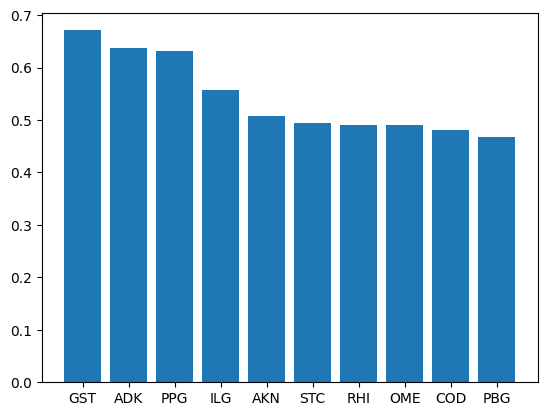

In [49]:
display(airports.sort_values(by='AVG_DELAY_RATE', ascending=False).head(10).reset_index(drop=True))

plt.bar(
    airports.sort_values(by='AVG_DELAY_RATE', ascending=False)['IATA_CODE'].head(10),
    airports.sort_values(by='AVG_DELAY_RATE', ascending=False)['AVG_DELAY_RATE'].head(10)
)
plt.show()

## Congestion Detection

In [55]:
airport_hour_df = (
    valid_flights
    .assign(hour=valid_flights['SCHEDULED_DEPARTURE']//100)
    .groupby(['ORIGIN_AIRPORT','hour'])
    .agg(
        flights=('FLIGHT_NUMBER','size'),
        avg_delay=('ARRIVAL_DELAY','mean')
    )
    .reset_index()
)

In [61]:
airport_hour_df

,ORIGIN_AIRPORT,hour,flights,avg_delay
0,ABE,6,814,0.324324
1,ABE,7,29,-8.206897
2,ABE,9,15,-3.333333
3,ABE,11,135,8.022222
4,ABE,12,317,6.100946
...,...,...,...,...
4241,YUM,15,188,2.324468
4242,YUM,16,110,4.754545
4243,YUM,17,24,20.708333
4244,YUM,18,154,2.681818


In [67]:
fig = px.scatter(
    airport_hour_df,
    x='flights',
    y='avg_delay',
    color='hour',
    trendline='ols',
    opacity=0.4,
    hover_data = {'ORIGIN_AIRPORT': True}
)

fig.show()

In [70]:
fig = px.scatter(
    airport_hour_df,
    x='hour',
    y='avg_delay',
    color='flights',
    trendline='ols',
    opacity=0.4,
    hover_data = {'ORIGIN_AIRPORT': True}
)

fig.show()

<Axes: xlabel='traffic_bin'>

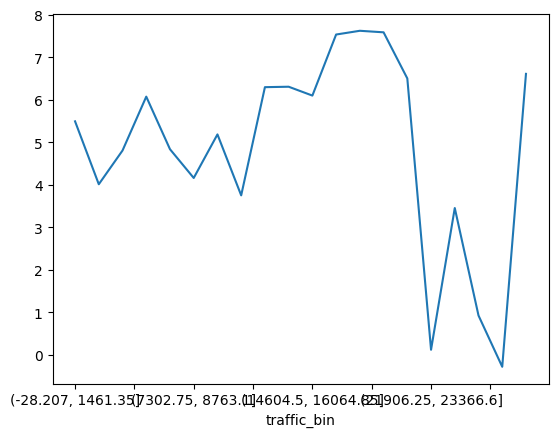

In [63]:
airport_hour_df['traffic_bin'] = pd.cut(
    airport_hour_df['flights'],
    bins=20
)

congestion_df = (
    airport_hour_df
    .groupby('traffic_bin')['avg_delay']
    .mean()
)

congestion_df.plot()

In [64]:
px.density_heatmap(
    airport_hour_df,
    x='hour',
    y='ORIGIN_AIRPORT',
    z='avg_delay'
)